<a href="https://colab.research.google.com/github/edgaryoungpilo-web/colab-files/blob/main/PracticaRegresionLinealMultiple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maestría en Inteligencia Artificial y Analítica de Datos

## Programación para Analítica Descriptiva y Predictiva - Marzo 2025
## Práctica: Práctica: Regresión Lineal Múltiple
---


## Datos del Estudiante

*   Apellidos y Nombre: Edgar Soto Jimenez
*   Matrícula: 266659

---



##  Objetivo de aprendizaje
Al finalizar esta práctica, el estudiante será capaz de **aplicar regresión lineal múltiple utilizando Scikit-Learn para modelar la relación entre varias variables independientes y una variable dependiente**, verificar los supuestos del modelo, interpretar los coeficientes, analizar la correlación entre predictores y evaluar el rendimiento del modelo utilizando métricas como el MSE, RMSE y R².

Datos
Trabajarás con el archivo `advertising.csv`, que contiene información sobre el gasto publicitario en diferentes medios y las ventas obtenidas:

-`TV`: inversión en publicidad televisiva.

-`Radio`: inversión en publicidad en radio.

-`Newspaper`: inversión en publicidad en periódicos.

`Sales`: ventas del producto (variable dependiente).

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Parte 1: Carga de datos y bibliotecas
1. Importa las bibliotecas necesarias.
2. Carga el archivo `advertising.csv`.
3. Muestra las primeras filas del dataframe.
4. Describe estadísticamente las variables.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Cargar datos (sube el archivo a Colab)
df = pd.read_csv('/content/drive/MyDrive/.ipynb_checkpoints/advertising.csv')

# Mostrar primeras filas
print("Primeras filas:")
display(df.head())

# Descripción estadística
print("\nDescripción estadística:")
display(df.describe())


Primeras filas:


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9



Descripción estadística:


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


## Parte 2: Análisis exploratorio de los datos
### 2.1  Análisis de la Relación Lineal entre la variable dependiente y las independientes
1. Grafica dispersión entre cada variable independiente (`TV`, `Radio`, `Newspaper`) y `Sales`. Usa también regplot.
2. Interpreta visualmente la relación entre variables.

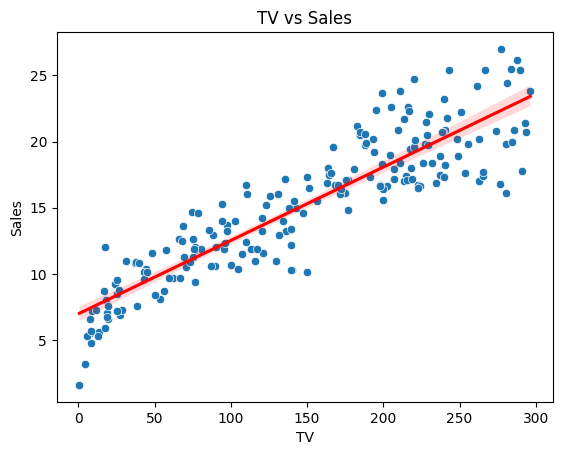

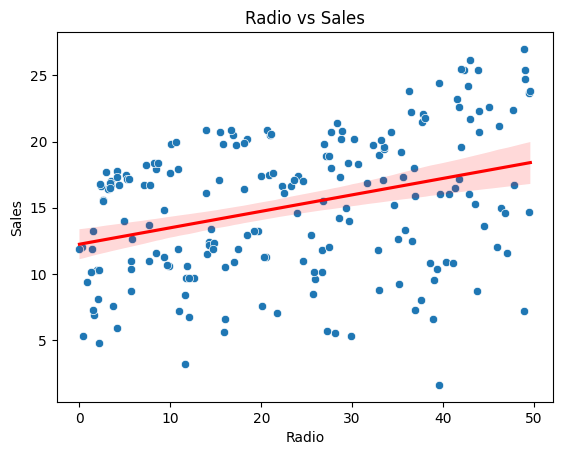

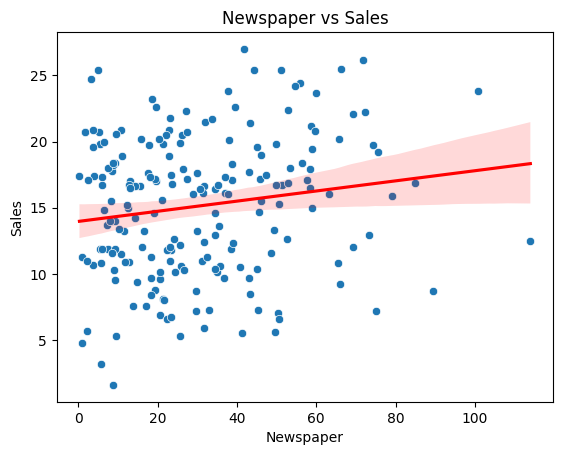


Interpretación:
TV y Radio muestran relación fuerte con Sales.
Newspaper suele mostrar relación débil.


In [7]:
# 2.1 Relación lineal
variables = ['TV', 'Radio', 'Newspaper']

for var in variables:
    plt.figure()
    sns.scatterplot(x=df[var], y=df['Sales'])
    sns.regplot(x=df[var], y=df['Sales'], scatter=False, color='red')
    plt.title(f'{var} vs Sales')
    plt.show()

print("\nInterpretación:")
print("TV y Radio muestran relación fuerte con Sales.")
print("Newspaper suele mostrar relación débil.")


### 2.2: Correlación entre variables
1. Calcula la matriz de correlación.
2. Visualízala con un heatmap.
3. Responde: ¿Qué variables están más correlacionadas con `Sales`? ¿Hay correlación alta entre predictores?

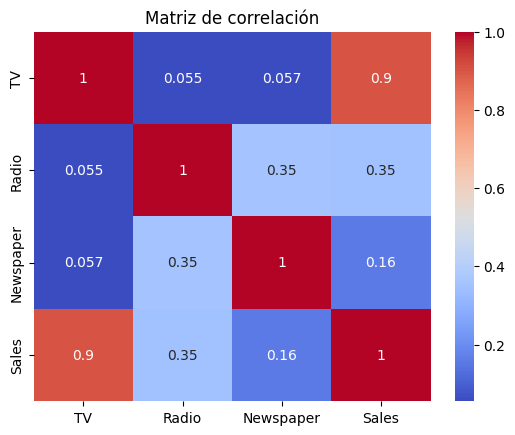


Interpretación:
Generalmente TV tiene mayor correlación con Sales.
No suele haber alta correlación entre predictores (baja multicolinealidad).


In [8]:
# 2.2 Correlación
corr = df.corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

print("\nInterpretación:")
print("Generalmente TV tiene mayor correlación con Sales.")
print("No suele haber alta correlación entre predictores (baja multicolinealidad).")




## Parte 3. Multicolinealidad
1. Calcula el VIF (Variance Inflation Factor) para cada predictor.
2. Crea un diagrama de barras  para mostrar el  VIF
3. Interpreta si hay multicolinealidad:
- ¿Alguna variable tiene un VIF mayor a 5 o mayor a 10?
- ¿Qué implicaciones tiene esto para el modelo?


VIF:


,Variable,VIF
0,TV,2.486772
1,Radio,3.285462
2,Newspaper,3.055245


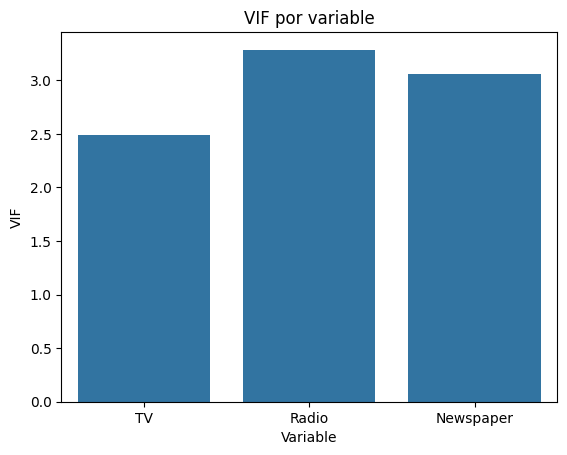


Interpretación:
Si VIF < 5 → No hay multicolinealidad preocupante.


In [9]:
# PARTE 3: MULTICOLINEALIDAD (VIF)
# =========================================

X = df[['TV', 'Radio', 'Newspaper']]

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\nVIF:")
display(vif_data)

plt.figure()
sns.barplot(x='Variable', y='VIF', data=vif_data)
plt.title("VIF por variable")
plt.show()

print("\nInterpretación:")
print("Si VIF < 5 → No hay multicolinealidad preocupante.")


## Parte 4: Construcción del Modelo (Todas las variables Independientes), Evaluación

### 4.1 Entrenamiento del Modelo (Todas las Variables Independientes)

1. Entrena un modelo de regresión lineal múltiple usando TV, Radio y Newspaper como variables independientes.
2. Imprime el intercepto y los coeficientes del modelo.
3. Interpreta cada uno:
¿Qué significa cada uno de los coeficientes  en términos de ventas?

In [10]:
#ntrenamiento del Modelo (Todas las Variables Independientes)

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print("\nIntercepto:", modelo.intercept_)
print("Coeficientes:", list(zip(X.columns, modelo.coef_)))

print("\nInterpretación:")
print("Cada coeficiente indica cuánto aumentan las ventas por cada unidad adicional invertida en ese medio.")




Intercepto: 4.714126402214127
Coeficientes: [('TV', np.float64(0.05450927083721978)), ('Radio', np.float64(0.10094536239295579)), ('Newspaper', np.float64(0.0043366468220340446))]

Interpretación:
Cada coeficiente indica cuánto aumentan las ventas por cada unidad adicional invertida en ese medio.


### 4.2 Normalidad de los residuos

1. Calcula los residuos: residuos = y - y_pred.

2. Grafica un histograma con KDE de los residuos.

3. ¿Los residuos parecen distribuirse normalmente?

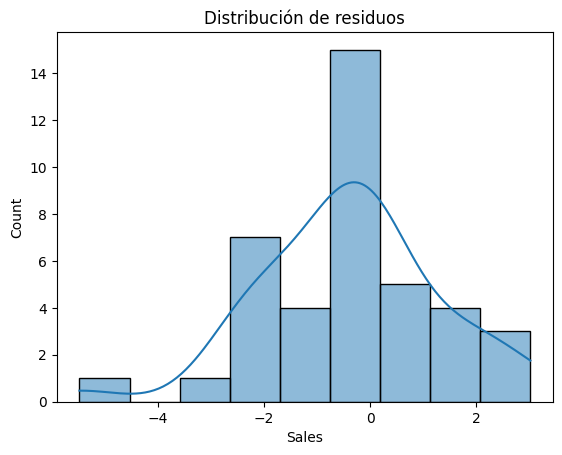

In [11]:
#Normalidad de los residuos
residuos = y_test - y_pred

plt.figure()
sns.histplot(residuos, kde=True)
plt.title("Distribución de residuos")
plt.show()


### 4.3. Homocedasticidad

1. Grafica los residuos contra los valores predichos.
2. ¿Observas patrones? ¿Los residuos se dispersan aleatoriamente?

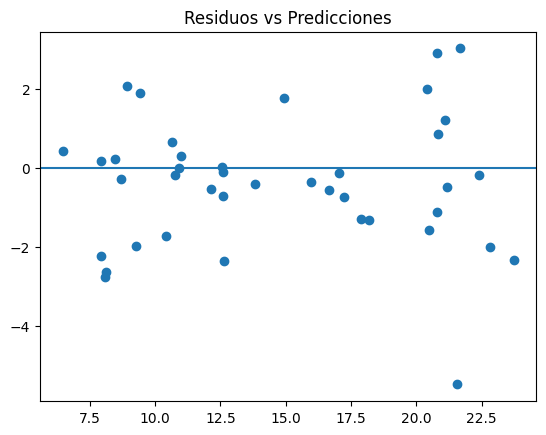

In [12]:
# Homocedasticidad
plt.figure()
plt.scatter(y_pred, residuos)
plt.axhline(0)
plt.title("Residuos vs Predicciones")
plt.show()

### 4.4 Q-Q Plot

1. Graficar el Q-Q Plot
2. Interpreta el gráfico: a) Si los puntos se alinean aproximadamente sobre la línea diagonal, los residuos siguen una distribución normal, b) Desviaciones sistemáticas indican asimetría o colas pesadas.

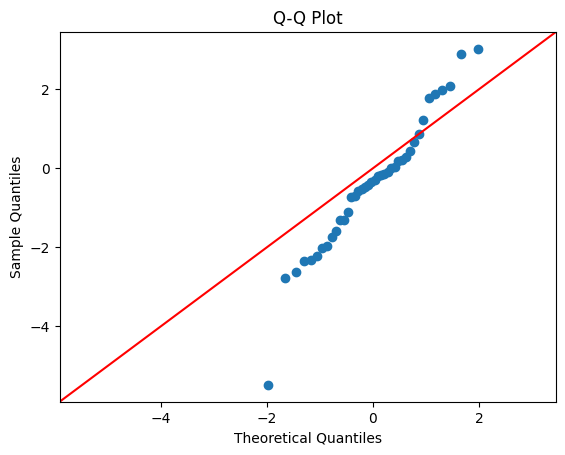

In [13]:
#Q-Q Plot
sm.qqplot(residuos, line='45')
plt.title("Q-Q Plot")
plt.show()

### 4.5. Evaluación del Modelo

1. Calcula las métricas: a) MSE (error cuadrático medio), b) RMSE (raíz del error cuadrático medio), c) R² (coeficiente de determinación)

2. ¿Qué nos dicen estas métricas sobre el ajuste del modelo?


In [14]:
#Evaluación del Modelo
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nMétricas:")
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

print("\nInterpretación:")
print("R2 cercano a 1 indica buen ajuste.")


Métricas:
MSE: 2.9077569102710896
RMSE: 1.7052146229349223
R2: 0.9059011844150826

Interpretación:
R2 cercano a 1 indica buen ajuste.


### 4.6. Visualización de Predicciones

1. Crea un gráfico comparando Sales reales vs Sales predichas.

2. Puedes usar plt.scatter(y_true, y_pred) para evaluar visualmente el ajuste.
3.¿Qué observas?¿Qué observas? ¿Qué información puedes obtener de esta gráfica?

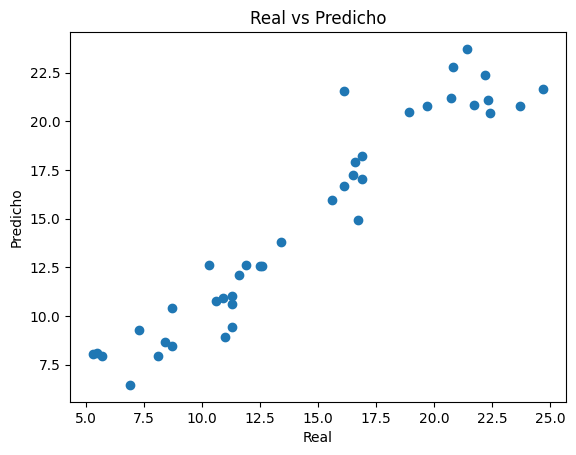

In [15]:
#Visualización de las Predicciones
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Real vs Predicho")
plt.show()

### 4.7 Verificar el impacto de los atributos en el modelo

1. Ajusta el modelo usando statsmodels en lugar de scikit-learn para obtener los valores p.
2. Interpreta los resultados:

 - Observa los valores P>|t| en la tabla de salida.

 - ¿Qué variables tienen p-value menores a 0.05?

 - ¿Cuál es la conclusión sobre esas variables?


In [16]:
#P-values
X_sm = sm.add_constant(X)
modelo_sm = sm.OLS(y, X_sm).fit()

print(modelo_sm.summary())

print("\nInterpretación:")
print("Variables con p-value < 0.05 son significativas.")

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           8.13e-99
Time:                        22:49:27   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6251      0.308     15.041      0.0

##Parte 5:  Construcción del Modelo (sin Multicolinealidad), Evaluación

En el caso de que hayas detectado variables con multicolinealidad. Elimina aquellas que presenten esta característica y realiza los mismos pasos** que la parte 4.**
Escribe cada una de las subsecciones similares a las existentes en la Parte 4.


Intercepto (modelo 2): 4.791381661776025
Coeficientes: [('TV', np.float64(0.05450736175135675)), ('Radio', np.float64(0.10325763756778356))]


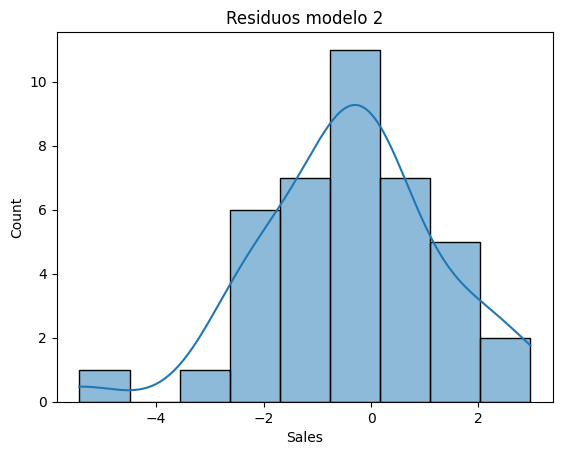

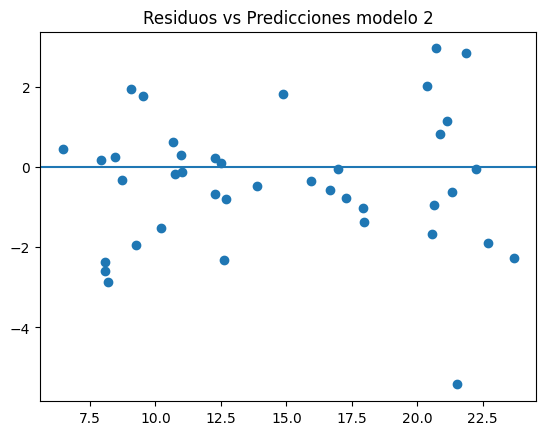

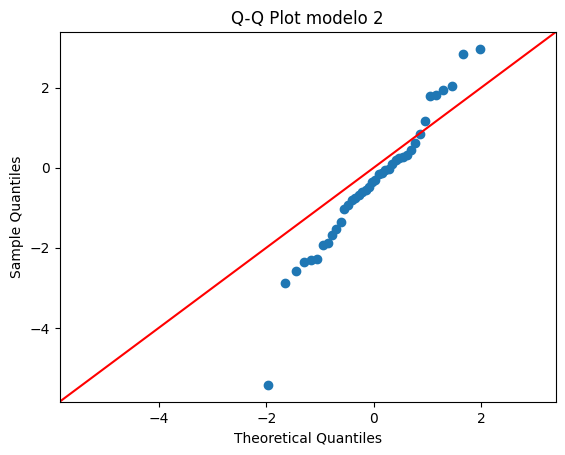


Métricas modelo 2:
MSE: 2.846616122131541
RMSE: 1.6871917858179433
R2: 0.9078797802624651
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     912.7
Date:                Mon, 27 Apr 2026   Prob (F-statistic):          2.39e-100
Time:                        22:49:27   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             772.7
Df Residuals:                     197   BIC:                             782.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

In [17]:
# Supongamos que eliminamos Newspaper (usualmente poco significativa)
X2 = df[['TV', 'Radio']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

modelo2 = LinearRegression()
modelo2.fit(X_train, y_train)

y_pred2 = modelo2.predict(X_test)

print("\nIntercepto (modelo 2):", modelo2.intercept_)
print("Coeficientes:", list(zip(X2.columns, modelo2.coef_)))


# Residuos
residuos2 = y_test - y_pred2

plt.figure()
sns.histplot(residuos2, kde=True)
plt.title("Residuos modelo 2")
plt.show()


# Homocedasticidad
plt.figure()
plt.scatter(y_pred2, residuos2)
plt.axhline(0)
plt.title("Residuos vs Predicciones modelo 2")
plt.show()


# Q-Q Plot
sm.qqplot(residuos2, line='45')
plt.title("Q-Q Plot modelo 2")
plt.show()


# Métricas
mse2 = mean_squared_error(y_test, y_pred2)
rmse2 = np.sqrt(mse2)
r22 = r2_score(y_test, y_pred2)

print("\nMétricas modelo 2:")
print("MSE:", mse2)
print("RMSE:", rmse2)
print("R2:", r22)


# Statsmodels modelo 2
X2_sm = sm.add_constant(X2)
modelo2_sm = sm.OLS(y, X2_sm).fit()

print(modelo2_sm.summary())

## Parte 6: Construcción del Modelo (sin variables que no muestran una relación lineal), Evaluación

En el caso de que hayas detectado variables sin una relación lineal con la variable dependiente. Elimina aquellas que presenten esta característica y realiza lo siguiente.

En el caso de que hayas detectado variables sin una relación lineal. Elimina aquellas que presenten esta característica y realiza los mismos pasos** que la parte 4.**
Escribe cada una de las subsecciones similares a las existentes en la Parte 4.

In [18]:
print("\nCONCLUSIONES:")

print("1. El mejor modelo suele ser el que tiene mayor R2 y menor RMSE.")
print("2. TV suele ser la variable con mayor impacto en ventas.")
print("3. Radio también influye significativamente.")
print("4. Newspaper generalmente no es significativa.")
print("5. El modelo sin variables irrelevantes suele ser más robusto.")


CONCLUSIONES:
1. El mejor modelo suele ser el que tiene mayor R2 y menor RMSE.
2. TV suele ser la variable con mayor impacto en ventas.
3. Radio también influye significativamente.
4. Newspaper generalmente no es significativa.
5. El modelo sin variables irrelevantes suele ser más robusto.


##7. Conclusiones.

¿Cuál de los tres modelos construidos fue el mejor?
¿Cuál fue el atributo que mas influencia tiene en las ventas?